
# Fitting NuSTAR Spectra: General Tutorial

A real example of fitting a NuSTAR spectrum.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.exceptions import VisibleDeprecationWarning
from parfive import Downloader

from sunkit_spex.legacy.fitting.fitter import Fitter, load

warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
except AttributeError:
    warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

Set up some plotting numbers



In [2]:
spec_single_plot_size = (8, 10)
spec_plot_size = (25, 10)
spec_font_size = 18
default_font_size = 10
x_limits, y_limits = [1.6, 8.5], [1e-1, 1e3]

Download the example data



In [3]:
# dl = Downloader()

# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/nustar/m3_time2628/"
# file_names = [
#     "nu80414202001A06_chu23_S_cl_grade0_sr.pha",
#     "nu80414202001A06_chu23_S_cl_grade0_sr.arf",
#     "nu80414202001A06_chu23_S_cl_grade0_sr.rmf",
# ]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

nu80414202001A06_chu23_S_cl_grade0_sr.arf:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

nu80414202001A06_chu23_S_cl_grade0_sr.pha:   0%|          | 0.00/132k [00:00<?, ?B/s]

nu80414202001A06_chu23_S_cl_grade0_sr.rmf:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

Load in one spectrum and fit it with one model



In [4]:
# First, load in your data files, here we load in 1 spectrum
_dir = "data/"
spec = Fitter(pha_file=[_dir + "nu80414202001A06_chu23_S_cl_grade0_sr.pha"])

All the data can be accessed via `spec.loaded_spec_data`

Next you can define a model, here we go for a single isothermal model



In [5]:
spec.model = "f_vth"

And all data can be accessed via `spec.params`.



In [6]:
print(spec.params)

              Status  Value       Bounds       Error
T1_spectrum1    free    1.0  (0.0, None)  (0.0, 0.0)
EM1_spectrum1   free    1.0  (0.0, None)  (0.0, 0.0)


Set your count energy fitting range. Here we choose 2.5--8.1 keV



In [7]:
spec.energy_fitting_range = [2.5, 8.1]

To set the initial value and boundary of your parameters we can do the following:



In [8]:
spec.params["T1_spectrum1"] = {"Value": 4, "Bounds": (2.5, 8)}  # units MK
spec.params["EM1_spectrum1"] = {"Value": 0.3, "Bounds": (1e-1, 8e-1)}  # units 1e46 cm^-3

Setting `spec.params["param_spec"] = string` will set the Status, `spec.params["param_spec"] = int or float` will set the Value, `spec.params["param_spec"] = tuple` will set the Bounds.

I.e., `spec.params["T1_spectrum1"] = {"Value":3.05, "Bounds":(2.5, 6)}` is the same as doing `spec.params["T1_spectrum1"]=3.05` and then `spec.params["T1_spectrum1"]=(2.5, 6)`.



In [9]:
print(spec.params)

              Status  Value      Bounds       Error
T1_spectrum1    free    4.0    (2.5, 8)  (0.0, 0.0)
EM1_spectrum1   free    0.3  (0.1, 0.8)  (0.0, 0.0)


Once data has been loaded and a model set then the data can be fitted.

Any kwargs passed to fit will be sent to Scipy's minimize. E.g., tol=1e-6 for setting a tolerance for the fit.



In [10]:
minimised_params = spec.fit()

The `spec.params` will be updated with the best fit values and errors (if obtained) too.



In [11]:
print(spec.params)

              Status     Value      Bounds  \
T1_spectrum1    free  4.758256    (2.5, 8)   
EM1_spectrum1   free  0.293765  (0.1, 0.8)   

                                                      Error  
T1_spectrum1     (0.06054753852486524, 0.06054753852486524)  
EM1_spectrum1  (0.022279038959463954, 0.022279038959463954)  


Plot the result with the `plot` method:



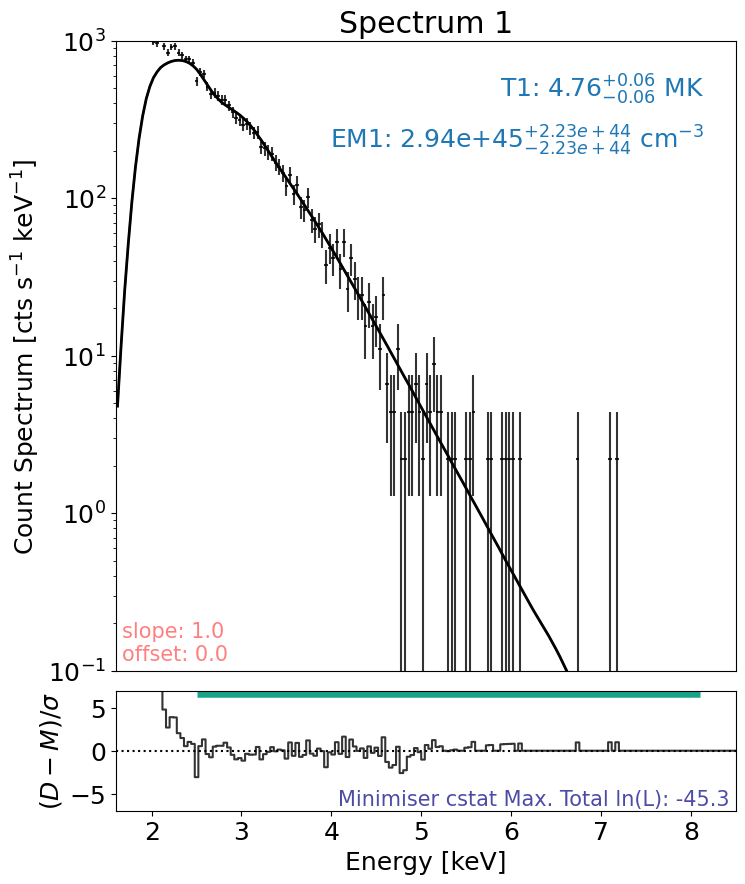

In [12]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)

# the only line needed to plot the result
axes, res_axes = spec.plot()

for a in axes:
    a.set_xlim(x_limits)
    a.set_ylim(y_limits)
plt.show()
plt.rcParams["font.size"] = default_font_size

**The data loader class**

The data loader class (`LoadSpec` in data_loader.py) makes use of instrument specific loaders. Each instrument loader's job is to essentially create the following dictionary for each loaded spectrum, found with the attribute `_loaded_spec_data` in the instrument class which makes up the loader class's `data.loaded_spec_data` dictionary. E.g., with NuSTAR:

```
  nust_loader._loaded_spec_data = {"photon_channel_bins":channel_bins,
                                 "photon_channel_mids":np.mean(channel_bins, axis=1),
                                 "photon_channel_binning":channel_binning,
                                 "count_channel_bins":channel_bins,
                                 "count_channel_mids":np.mean(channel_bins, axis=1),
                                 "count_channel_binning":channel_binning,
                                 "counts":counts,
                                 "count_error":count_error,
                                 "count_rate":count_rate,
                                 "count_rate_error":count_rate_error,
                                 "effective_exposure":eff_exp,
                                 "srm":srm,
                                 "extras":{"pha.file":f_pha,
                                           "arf.file":f_arf,
                                           "arf.e_lo":e_lo_arf,
                                           "arf.e_hi":e_hi_arf,
                                           "arf.effective_area":eff_area,
                                           "rmf.file":f_rmf,
                                           "rmf.e_lo":e_lo_rmf,
                                           "rmf.e_hi":e_hi_rmf,
                                           "rmf.ngrp":ngrp,
                                           "rmf.fchan":fchan,
                                           "rmf.nchan":nchan,
                                           "rmf.matrix":matrix,
                                           "rmf.redistribution_matrix":redist_m}
                                }
```
such that, ``spec.data.loaded_spec_data == {"spectrum1":nust_loader._loaded_spec_data, ...}``

**Multiple ways to set the fitting range**

Fit the energy range while missing bins:

This only will fit the counts from 2.5--4 keV and 4.5--8.1 keV and is applied to all spectra loaded



In [13]:
spec.energy_fitting_range = [[2.5, 4], [4.5, 8.1]]

**Rebin the data (not just for plotting)**

Rebin all the count data being fitted to have a minimum of 4 counts in a bin, any counts left over will not be included and the user will be told.



In [14]:
spec.rebin = 4
# or equivalently
spec.rebin = {"all": 4}
# or equivalently if just one spectrum is loaded
spec.rebin = {"spectrum1": 4}

**Undo the rebinning of the data**

To revert back to native binning for all spectra:



In [15]:
# For one spectrum
spec.undo_rebin = "spectrum1"
# or (indicate the spectrum with just its number)
spec.undo_rebin = 1
# or explicitly state the rebinning should be reverted to all spectra
spec.undo_rebin = "all"

**Save what you have**

To save the fitting class to a file called 'test.pickle'.



In [16]:
spec.save("./test.pickle")

Load it back in and continue analysis:

To load a saved session back in



In [17]:
new_spec = load("./test.pickle")

print(new_spec.params)

              Status     Value      Bounds  \
T1_spectrum1    free  4.758256    (2.5, 8)   
EM1_spectrum1   free  0.293765  (0.1, 0.8)   

                                                      Error  
T1_spectrum1     (0.06054753852486524, 0.06054753852486524)  
EM1_spectrum1  (0.022279038959463954, 0.022279038959463954)  


run fit again since the energy range being fitted over has been changed after the last fit



In [18]:
new_spec.fit(tol=1e-6)  # Scipy minimize tolerance of 1e-6

[4.717251178489729, 0.30766783569520506]

Plot the data and rebin it (*just for plotting*), fit was in natural binning

`rebin=10` means the count bins were combined so that all bins had at least 10 counts in them or were ignored



2026-07-16T23:00:48Z INFO sunkit_spex.legacy.fitting.fitter 2814: Apply binning for plotting.


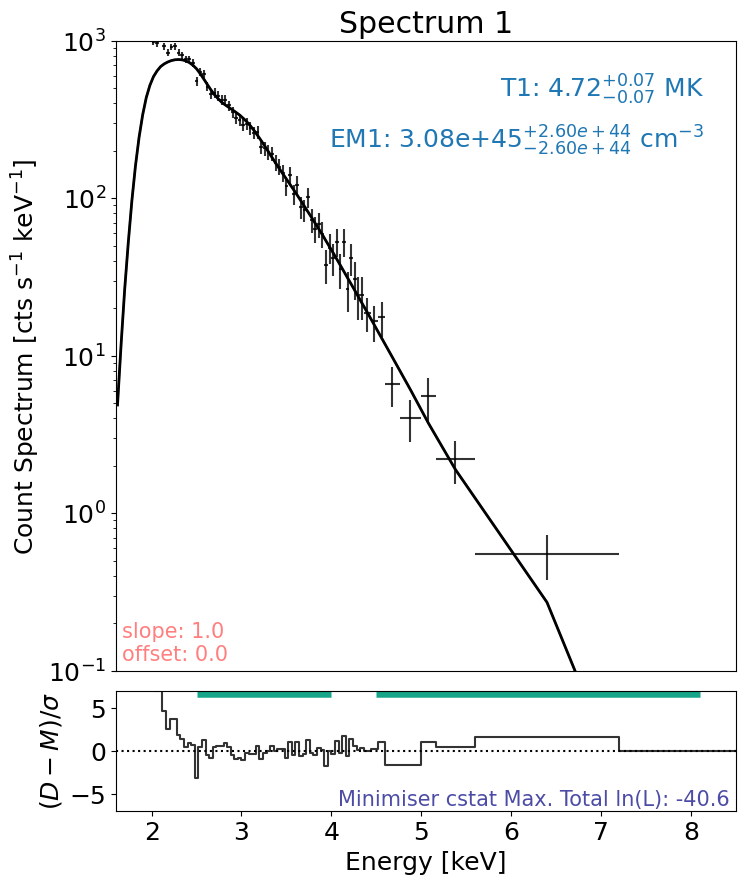

In [19]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)
axes, res_axes = new_spec.plot(rebin=10)
for a in axes:
    a.set_xlim(x_limits)
    a.set_ylim(y_limits)
plt.show()
plt.rcParams["font.size"] = default_font_size

Easily run an MCMC on your data with your model



In [20]:
mcmc_result = spec.run_mcmc(steps_per_walker=100)

100%|██████████| 100/100 [00:04<00:00, 22.27it/s]


To add more MCMC runs, avoid overwriting by setting  `append_runs=True`.



In [21]:
mcmc_result = spec.run_mcmc(steps_per_walker=50, append_runs=True)

100%|██████████| 50/50 [00:02<00:00, 19.41it/s]


MCMC runs are easily burned and are always burned from the original sampling. E.g., burning 50 samples twice still only discards 50 samples, to discard 100 the user needs to just discard 100.



In [22]:
spec.burn_mcmc = 30

Plot the log-probability chains



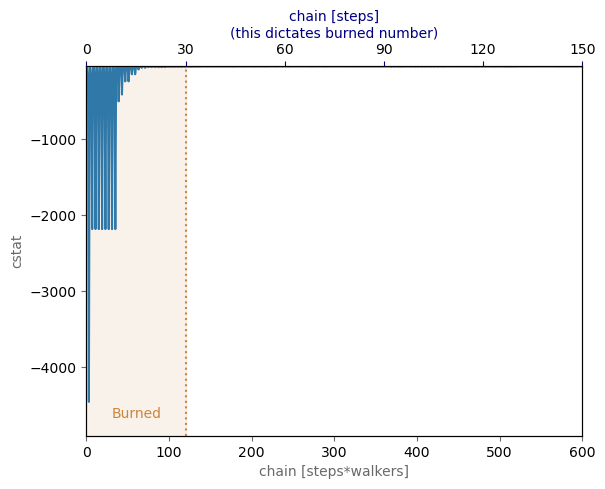

In [23]:
plt.figure()
spec.plot_log_prob_chain()
plt.show()

Plot the corner plot from the MCMC run (just send the data to corner.py)



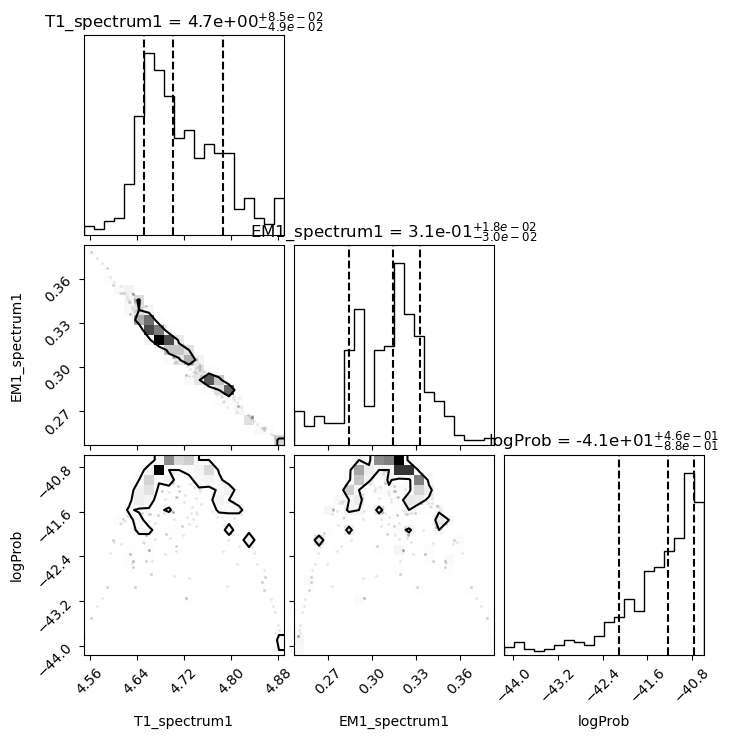

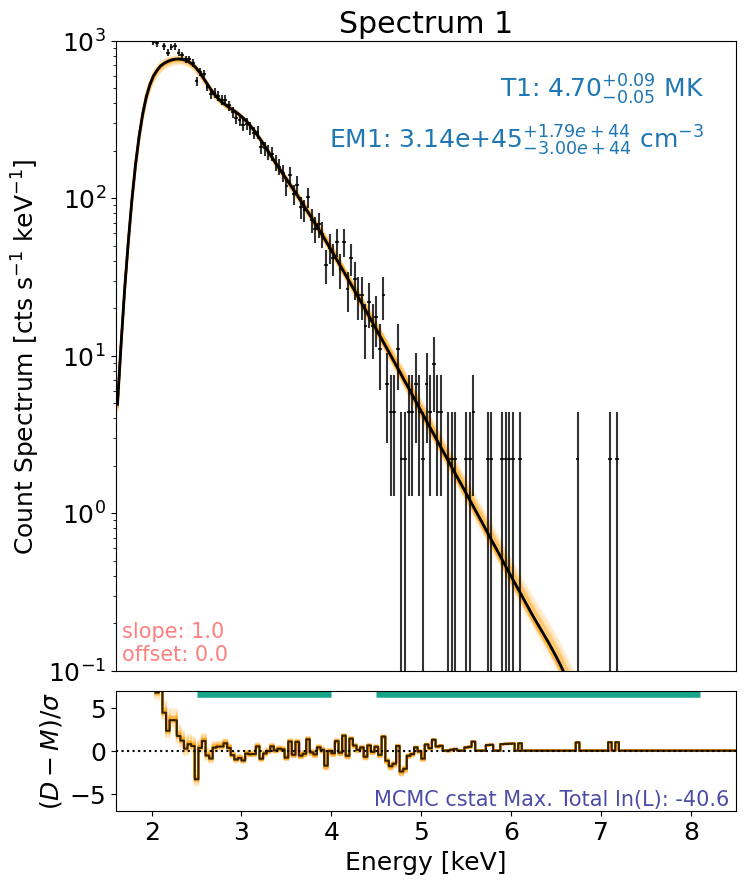

In [24]:
corner_plot = spec.corner_mcmc()

plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(x_limits)
    a.set_ylim(y_limits)
plt.show()
plt.rcParams["font.size"] = default_font_size

**Note** that the log-likelihood displayed on the spectral plots show the the maximum log-likelihood found in the MCMC run, not the log-likelihood of the maximum a posteriori (MAP) fit plotted.

The log-likelihoods of the median and confidence ranges can be found on the corner plot at the minute and the parameter values that produce these can be found with the `mcmc_table` attribute.



In [25]:
spec.mcmc_table

Param,LowB,Mid,HighB,MaxLog
str13,float64,float64,float64,float64
T1_spectrum1,4.65,4.70,4.79,4.72
EM1_spectrum1,0.28,0.31,0.33,0.31


An alternative to plotting a number of random MCMC samples as faded lines, the user can plot a colour map showing where all run models (that are not burned) accumulate counts. This will obviously take longer.



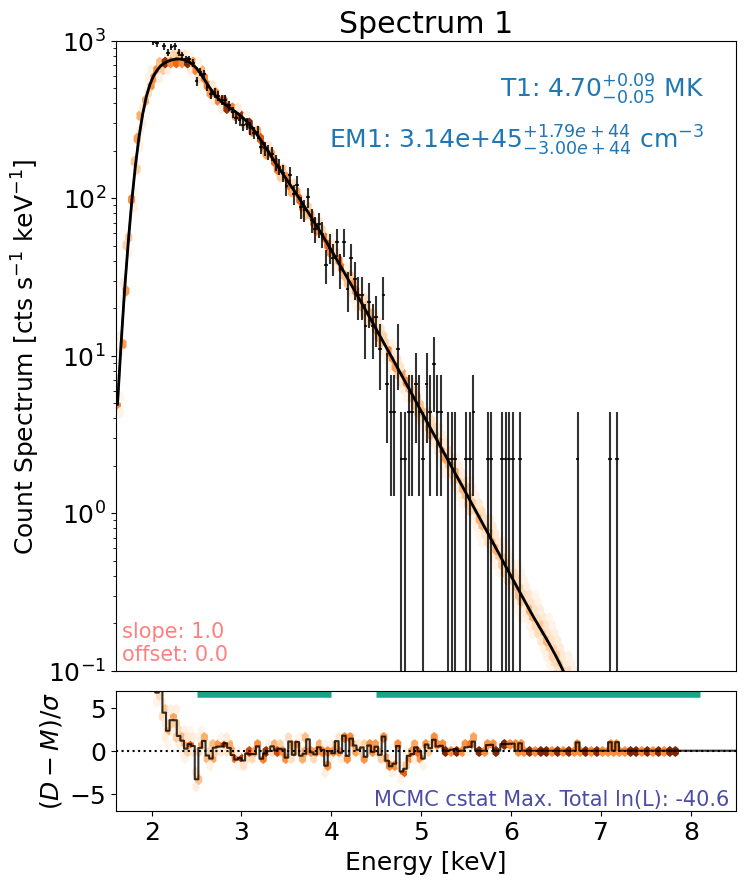

In [26]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)
axes, res_axes = spec.plot(hex_grid=True)
for a in axes:
    a.set_xlim(x_limits)
    a.set_ylim(y_limits)
plt.show()
plt.rcParams["font.size"] = default_font_size